<a href="https://colab.research.google.com/github/skolix15/Deep_Convolutional_Neural_Networks/blob/main/dcnn_cifar10_resnet18_executed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN Assignment 1 — Feature Extraction vs Fine-tuning
**Dataset:** CIFAR-10 | **Model:** ResNet18 pretrained on ImageNet

## Research Question
Is it worth unfreezing the last layers of ResNet18 (fine-tuning), or is it enough to only train the final FC layer (feature extraction)?

## Structure
1. Imports & setup
2. CIFAR-10 data loading
3. Model A: Feature Extraction (head only)
4. Model B: Fine-tuning (head + last 2 residual blocks)
5. Training and evaluation
6. Comparison — accuracy, loss curves, confusion matrix
7. Grad-CAM visualization

## 1. Imports & Setup

In [2]:
# --- Core deep learning framework ---
# PyTorch is the main library we use to build and train neural networks.
# torch.nn contains all layer types (Conv, Linear, BatchNorm, etc.)
# torch.optim contains optimizers (Adam, SGD, etc.)
import torch
import torch.nn as nn
import torch.optim as optim

# --- Computer vision utilities ---
# torchvision gives us: pretrained models, standard datasets (CIFAR-10),
# and image transforms (resize, normalize, augment)
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

# --- Standard utilities ---
import numpy as np
import matplotlib.pyplot as plt
import time   # to measure training duration
import copy   # to save a deep copy of the best model weights

# --- Evaluation metrics (from sklearn, not PyTorch) ---
# We use sklearn only for evaluation, NOT for training the CNN.
# confusion_matrix: shows which classes get confused with each other
# classification_report: precision, recall, F1 per class
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns  # nicer heatmap plots

# --- Device setup ---
# We try to use GPU (CUDA) for training — it's ~10-20x faster than CPU.
# In Colab: Runtime -> Change runtime type -> T4 GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# --- Global hyperparameters ---
# These are the values we control before training starts.
# Changing them will affect training speed and final accuracy.
EPOCHS = 15          # how many full passes over the training data
BATCH_SIZE = 128     # how many images to process at once before updating weights
NUM_CLASSES = 10     # CIFAR-10 has 10 categories
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

Using device: cuda
GPU: Tesla T4


## 2. Data Loading — CIFAR-10

In [3]:
# --- Why we resize to 224x224 ---
# CIFAR-10 images are only 32x32 pixels.
# ResNet18 was trained on ImageNet with 224x224 images, so its first
# conv layer (7x7 kernel) expects a larger spatial input.
# If we feed 32x32 directly, the feature maps collapse too quickly.
# Solution: resize every image to 224x224 before feeding into ResNet.

# --- Why we use ImageNet mean/std for normalization ---
# Normalization: (pixel - mean) / std  → values roughly in [-2, 2]
# ResNet18 was trained with inputs normalized using ImageNet statistics.
# Using the same normalization keeps the pretrained weights in a valid
# operating range — the network "expects" this distribution.
IMAGENET_MEAN = [0.485, 0.456, 0.406]  # mean per R, G, B channel
IMAGENET_STD  = [0.229, 0.224, 0.225]  # std  per R, G, B channel

# --- Training transforms (with data augmentation) ---
# Data augmentation artificially increases dataset diversity.
# RandomHorizontalFlip: randomly mirrors the image left-right (50% chance)
# RandomCrop: randomly crops a 224x224 patch with 8px padding around edges
# These force the model to learn features that are position/orientation invariant.
# NOTE: augmentation is applied ONLY to training data, never to val/test.
train_transform = transforms.Compose([
    transforms.Resize(224),              # upsample from 32x32 to 224x224
    transforms.RandomHorizontalFlip(),   # augmentation: random mirror
    transforms.RandomCrop(224, padding=8),  # augmentation: random crop
    transforms.ToTensor(),               # convert PIL image to tensor, scales to [0, 1]
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)  # normalize
])

# --- Validation/Test transforms (NO augmentation) ---
# For evaluation we want deterministic results — no random flips or crops.
# Just resize and normalize, same as the training data distribution.
val_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# --- Download and load CIFAR-10 ---
# train=True  → 50,000 training images
# train=False → 10,000 test images
# download=True automatically fetches the dataset the first time
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=val_transform
)

# --- Validation split ---
# We carve out 10% of the training set as validation data.
# Validation is used to monitor overfitting DURING training (not for final score).
# The test set is only used ONCE at the very end.
val_size   = int(0.1 * len(train_dataset))  # 5,000 images
train_size = len(train_dataset) - val_size  # 45,000 images
train_set, val_set = torch.utils.data.random_split(train_dataset, [train_size, val_size])

# --- DataLoaders ---
# A DataLoader handles batching, shuffling, and parallel data loading.
# shuffle=True for training: we want a different batch order each epoch
# shuffle=False for val/test: order doesn't matter for evaluation
# num_workers=2: use 2 CPU threads to load data in parallel (faster)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = torch.utils.data.DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_dataset)}')

100%|██████████| 170M/170M [00:12<00:00, 13.3MB/s]


Train: 45000 | Val: 5000 | Test: 10000


## 3. Build Models

In [4]:
# =============================================================================
# MODEL A — Feature Extraction
# =============================================================================
# Strategy: freeze ALL layers of ResNet18, replace only the final FC layer.
#
# Why this works:
#   ResNet18 trained on ImageNet has already learned general-purpose features:
#   - Early layers: edges, gradients, color blobs
#   - Middle layers: textures, shapes, object parts
#   These features transfer well to CIFAR-10 because natural images share
#   the same low-level structure regardless of the specific task.
#
# What we train:
#   Only the new FC layer: 512 inputs → 10 outputs
#   That's only ~5,000 parameters — very fast to train.
#
# Limitation:
#   The last conv layers of ResNet were tuned for ImageNet's 1000 classes.
#   They may not produce the most discriminative features for CIFAR-10.
# =============================================================================
def build_feature_extraction():
    # Load ResNet18 with weights pretrained on ImageNet
    # These weights encode ~11 million parameters learned from 1.2M images
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Freeze ALL parameters: set requires_grad=False
    # This means PyTorch will NOT compute gradients for these parameters,
    # so they will NOT be updated during backpropagation.
    for param in model.parameters():
        param.requires_grad = False

    # Replace the original FC head: Linear(512 → 1000) with Linear(512 → 10)
    # model.fc.in_features = 512 (the output size of ResNet's avgpool)
    # Newly created layers have requires_grad=True by default, so only
    # this layer will be updated during training.
    in_features = model.fc.in_features  # 512
    model.fc = nn.Sequential(
        nn.Dropout(0.3),              # randomly zero 30% of neurons → reduces overfitting
        nn.Linear(in_features, NUM_CLASSES)  # final classification layer
    )
    return model


# =============================================================================
# MODEL B — Fine-tuning
# =============================================================================
# Strategy: freeze early layers, UNFREEZE the last 2 residual blocks + new head.
#
# ResNet18 architecture (simplified):
#   conv1 → layer1 → layer2 → layer3 → layer4 → avgpool → fc
#   [frozen]  [frozen] [frozen] [TRAIN]  [TRAIN]            [TRAIN]
#
# Why unfreeze layer3 and layer4?
#   These layers learn high-level, task-specific features (object parts,
#   class-specific patterns). By allowing them to update, the network can
#   adapt these representations to CIFAR-10's specific visual patterns.
#
# Why use a SMALLER learning rate (1e-4 instead of 1e-3)?
#   The pretrained weights in layer3/layer4 are already good.
#   A large lr would destroy these learned representations ("catastrophic forgetting").
#   A small lr gently nudges them toward CIFAR-10 without forgetting ImageNet knowledge.
#
# Trade-off vs Feature Extraction:
#   + Higher accuracy potential (layers adapt to the target domain)
#   - More trainable parameters (~2.8M vs ~5K)
#   - Slower training
#   - Risk of overfitting if dataset is small
# =============================================================================
def build_fine_tuning():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Step 1: freeze everything (same starting point as feature extraction)
    for param in model.parameters():
        param.requires_grad = False

    # Step 2: selectively unfreeze the last two residual blocks
    # layer3 contains 2 residual blocks that learn mid/high-level features
    # layer4 contains 2 residual blocks that learn the most abstract features
    for param in model.layer3.parameters():
        param.requires_grad = True
    for param in model.layer4.parameters():
        param.requires_grad = True

    # Step 3: replace the classification head (same as feature extraction)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, NUM_CLASSES)
    )
    return model


def count_trainable_params(model):
    # Count only parameters with requires_grad=True
    # These are the parameters that will actually be updated during training
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Instantiate both models and move them to GPU (if available)
# .to(device) copies the model parameters to GPU memory
model_fe = build_feature_extraction().to(device)
model_ft = build_fine_tuning().to(device)

print(f'Feature Extraction — trainable params: {count_trainable_params(model_fe):,}')
print(f'Fine-tuning        — trainable params: {count_trainable_params(model_ft):,}')
# Expected output:
# Feature Extraction — trainable params: 5,130
# Fine-tuning        — trainable params: ~2,800,000

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 133MB/s]


Feature Extraction — trainable params: 5,130
Fine-tuning        — trainable params: 10,498,570


## 4. Training Loop

In [5]:
def train_model(model, train_loader, val_loader, epochs, lr, model_name):
    """
    Train a model for a given number of epochs and return:
      - the model with the best validation accuracy (not the last epoch)
      - training history (loss/accuracy per epoch)
      - total training time in seconds
    """

    # --- Loss function ---
    # CrossEntropyLoss = Softmax + Negative Log Likelihood combined.
    # For a batch of predictions and true labels, it computes:
    #   L = -log( exp(z_y) / sum(exp(z_j)) )  where z_y is the score for the true class
    # The model is penalized more when it is confident AND wrong.
    criterion = nn.CrossEntropyLoss()

    # --- Optimizer ---
    # Adam (Adaptive Moment Estimation) is generally the best default optimizer.
    # It adapts the learning rate per parameter using gradient history.
    # IMPORTANT: we pass only the parameters with requires_grad=True.
    # Passing frozen parameters would waste memory and time.
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    # --- Learning rate scheduler ---
    # StepLR multiplies the learning rate by gamma every step_size epochs.
    # Here: lr is halved every 5 epochs (0.5^1=0.5, 0.5^2=0.25, ...)
    # This helps the model converge: start with larger steps, then fine-tune.
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    # --- History dict to track metrics per epoch ---
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    # --- Best model tracking ---
    # We save the weights with the highest validation accuracy.
    # This prevents using an overfitted model from a later epoch.
    best_val_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())  # full copy of all tensors
    start = time.time()

    for epoch in range(epochs):

        # =====================================================================
        # TRAINING PHASE
        # =====================================================================
        # model.train() enables:
        #   - Dropout (randomly zeroes neurons during forward pass)
        #   - BatchNorm in training mode (uses batch statistics, not running stats)
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:

            # Move data to the same device as the model (GPU or CPU)
            inputs, labels = inputs.to(device), labels.to(device)

            # Zero gradients from previous batch.
            # PyTorch accumulates gradients by default — we reset them each step.
            optimizer.zero_grad()

            # Forward pass: compute predictions
            # outputs shape: (batch_size, NUM_CLASSES) — raw logits, not probabilities
            outputs = model(inputs)

            # Compute loss between predictions and true labels
            loss = criterion(outputs, labels)

            # Backward pass: compute gradients of loss w.r.t. all trainable parameters
            # ∂L/∂W is computed for every parameter with requires_grad=True
            loss.backward()

            # Update weights: W = W - lr * ∂L/∂W (simplified; Adam is more complex)
            optimizer.step()

            # Accumulate stats for this batch
            running_loss += loss.item() * inputs.size(0)  # sum of losses (not mean)
            _, predicted = outputs.max(1)  # argmax across class dimension
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / total
        train_acc  = correct / total

        # =====================================================================
        # VALIDATION PHASE
        # =====================================================================
        # model.eval() disables Dropout and switches BatchNorm to use
        # running (population) statistics instead of batch statistics.
        # torch.no_grad() disables gradient computation entirely → faster + less memory.

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():

            for inputs, labels in val_loader:

                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss    += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                val_total   += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss /= val_total
        val_acc   = val_correct / val_total

        # Save weights if this is the best validation accuracy so far
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())

        # Record history for plotting later
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Step the learning rate scheduler (called once per epoch, not per batch)
        scheduler.step()

        print(
            f'[{model_name}] Epoch {epoch+1:2d}/{epochs} | '
            f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
            f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}'
        )

    elapsed = time.time() - start
    print(f'\n{model_name} — Best Val Acc: {best_val_acc:.4f} | Time: {elapsed:.1f}s')

    # Restore the best weights (not necessarily from the last epoch)
    model.load_state_dict(best_weights)
    return model, history, elapsed

In [6]:
# --- Train Model A: Feature Extraction ---
# lr=1e-3: higher learning rate is fine here because only the new FC head
# is being trained — there are no pretrained weights to protect.
print('=' * 60)
print('TRAINING: Feature Extraction')
print('Only the final FC layer (5,130 params) is updated.')
print('=' * 60)
model_fe, history_fe, time_fe = train_model(
    model_fe,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=1e-3,
    model_name='FeatureExtraction'
)

TRAINING: Feature Extraction
Only the final FC layer (5,130 params) is updated.
[FeatureExtraction] Epoch  1/15 | Train Loss: 1.0857 Acc: 0.6403 | Val Loss: 0.7033 Acc: 0.7690
[FeatureExtraction] Epoch  2/15 | Train Loss: 0.7979 Acc: 0.7269 | Val Loss: 0.6359 Acc: 0.7836
[FeatureExtraction] Epoch  3/15 | Train Loss: 0.7697 Acc: 0.7361 | Val Loss: 0.6158 Acc: 0.7960
[FeatureExtraction] Epoch  4/15 | Train Loss: 0.7672 Acc: 0.7347 | Val Loss: 0.6075 Acc: 0.7916
[FeatureExtraction] Epoch  5/15 | Train Loss: 0.7600 Acc: 0.7369 | Val Loss: 0.6226 Acc: 0.7878
[FeatureExtraction] Epoch  6/15 | Train Loss: 0.7528 Acc: 0.7383 | Val Loss: 0.5836 Acc: 0.8014
[FeatureExtraction] Epoch  7/15 | Train Loss: 0.7466 Acc: 0.7412 | Val Loss: 0.5924 Acc: 0.7998
[FeatureExtraction] Epoch  8/15 | Train Loss: 0.7514 Acc: 0.7410 | Val Loss: 0.5788 Acc: 0.8080
[FeatureExtraction] Epoch  9/15 | Train Loss: 0.7441 Acc: 0.7437 | Val Loss: 0.5886 Acc: 0.8012
[FeatureExtraction] Epoch 10/15 | Train Loss: 0.7448 Acc

In [7]:
# --- Train Model B: Fine-tuning ---
# lr=1e-4: much smaller learning rate to avoid overwriting the pretrained
# weights in layer3/layer4 too aggressively (catastrophic forgetting).
# The idea: nudge the pretrained features toward CIFAR-10, don't reset them.
print('=' * 60)
print('TRAINING: Fine-tuning')
print('layer3, layer4, and the new FC head are all updated.')
print('=' * 60)
model_ft, history_ft, time_ft = train_model(
    model_ft,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=1e-4,
    model_name='FineTuning'
)

TRAINING: Fine-tuning
layer3, layer4, and the new FC head are all updated.
[FineTuning] Epoch  1/15 | Train Loss: 0.4345 Acc: 0.8580 | Val Loss: 0.2171 Acc: 0.9238
[FineTuning] Epoch  2/15 | Train Loss: 0.1809 Acc: 0.9402 | Val Loss: 0.1895 Acc: 0.9340
[FineTuning] Epoch  3/15 | Train Loss: 0.1187 Acc: 0.9604 | Val Loss: 0.1607 Acc: 0.9434
[FineTuning] Epoch  4/15 | Train Loss: 0.0840 Acc: 0.9729 | Val Loss: 0.1637 Acc: 0.9412
[FineTuning] Epoch  5/15 | Train Loss: 0.0620 Acc: 0.9804 | Val Loss: 0.1610 Acc: 0.9488
[FineTuning] Epoch  6/15 | Train Loss: 0.0327 Acc: 0.9909 | Val Loss: 0.1452 Acc: 0.9514
[FineTuning] Epoch  7/15 | Train Loss: 0.0255 Acc: 0.9927 | Val Loss: 0.1589 Acc: 0.9494
[FineTuning] Epoch  8/15 | Train Loss: 0.0189 Acc: 0.9954 | Val Loss: 0.1467 Acc: 0.9534
[FineTuning] Epoch  9/15 | Train Loss: 0.0174 Acc: 0.9955 | Val Loss: 0.1561 Acc: 0.9516
[FineTuning] Epoch 10/15 | Train Loss: 0.0137 Acc: 0.9969 | Val Loss: 0.1629 Acc: 0.9486
[FineTuning] Epoch 11/15 | Train Lo

## 5. Evaluation on the Test Set

In [8]:
def evaluate(model, loader):
    """
    Run the model on a dataset and collect all predictions and true labels.
    Returns numpy arrays so we can use sklearn metrics.
    """
    model.eval()  # disable dropout, use running BatchNorm stats
    all_preds, all_labels = [], []

    with torch.no_grad():  # no gradient computation needed for inference

        for inputs, labels in loader:

            inputs = inputs.to(device)
            outputs = model(inputs)       # shape: (batch, 10) — raw logits
            _, preds = outputs.max(1)     # take class with highest logit
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)


# Run evaluation on the held-out test set (never seen during training)
labels_fe, preds_fe = evaluate(model_fe, test_loader)
labels_ft, preds_ft = evaluate(model_ft, test_loader)

acc_fe = (labels_fe == preds_fe).mean()
acc_ft = (labels_ft == preds_ft).mean()

print(f'Test Accuracy — Feature Extraction : {acc_fe*100:.2f}%')
print(f'Test Accuracy — Fine-tuning        : {acc_ft*100:.2f}%')
print(f'Accuracy gain from fine-tuning     : {(acc_ft - acc_fe)*100:+.2f}%')
# Expected: Fine-tuning should be ~3-7% higher than Feature Extraction

Test Accuracy — Feature Extraction : 79.19%
Test Accuracy — Fine-tuning        : 94.95%
Accuracy gain from fine-tuning     : +15.76%


## 6. Comparison — Learning Curves & Confusion Matrix

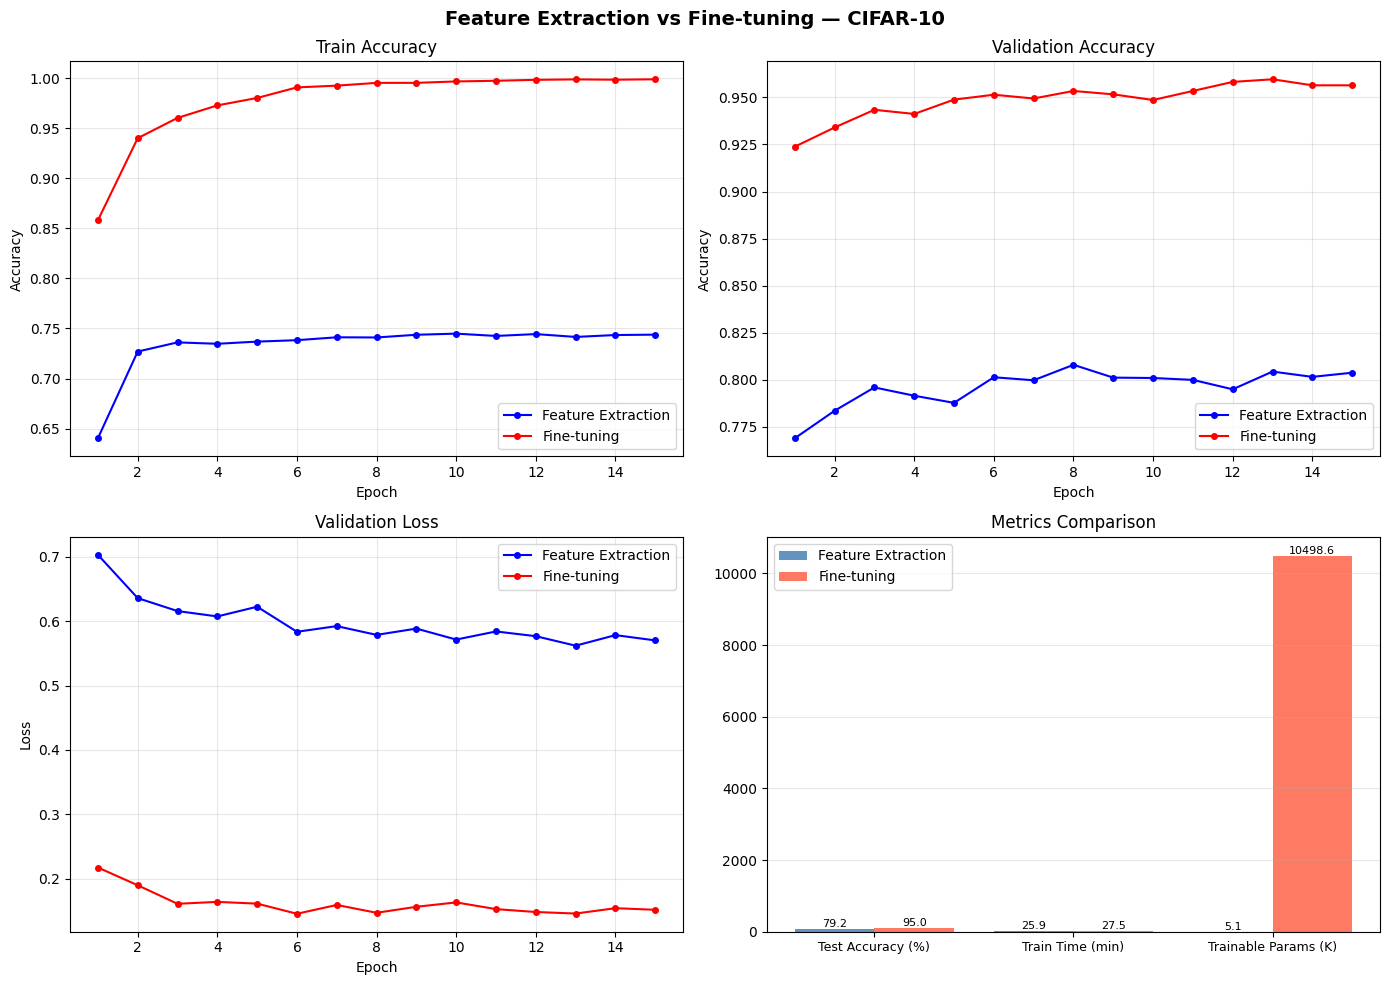

Saved: comparison_curves.png


In [9]:
# --- Learning Curves ---
# These plots tell you:
#   Train Accuracy: how well the model fits the training data
#   Val Accuracy:   how well it generalizes to unseen data
#
# What to look for:
#   - If train acc >> val acc → overfitting (model memorized training data)
#   - If both are low → underfitting (model too simple or undertrained)
#   - Ideal: both curves converge and stay close together
#
# Fine-tuning typically shows a steeper initial rise in val accuracy
# because more layers are adapting to the target distribution.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Extraction vs Fine-tuning — CIFAR-10', fontsize=14, fontweight='bold')

epochs_range = range(1, EPOCHS + 1)

# Plot 1: Training Accuracy
axes[0, 0].plot(epochs_range, history_fe['train_acc'], 'b-o', markersize=4, label='Feature Extraction')
axes[0, 0].plot(epochs_range, history_ft['train_acc'], 'r-o', markersize=4, label='Fine-tuning')
axes[0, 0].set_title('Train Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Validation Accuracy — the most important curve
# This is what matters for the final comparison
axes[0, 1].plot(epochs_range, history_fe['val_acc'], 'b-o', markersize=4, label='Feature Extraction')
axes[0, 1].plot(epochs_range, history_ft['val_acc'], 'r-o', markersize=4, label='Fine-tuning')
axes[0, 1].set_title('Validation Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Validation Loss
# If val loss starts rising while train loss keeps falling → overfitting
axes[1, 0].plot(epochs_range, history_fe['val_loss'], 'b-o', markersize=4, label='Feature Extraction')
axes[1, 0].plot(epochs_range, history_ft['val_loss'], 'r-o', markersize=4, label='Fine-tuning')
axes[1, 0].set_title('Validation Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Summary bar chart
# Summarizes the 3 key dimensions of comparison:
#   - Test Accuracy: which model performs better?
#   - Training time: how much longer does fine-tuning take?
#   - Trainable params: how much more complex is fine-tuning?
metrics = ['Test Accuracy (%)', 'Train Time (min)', 'Trainable Params (K)']
fe_vals = [acc_fe * 100, time_fe / 60, count_trainable_params(model_fe) / 1000]
ft_vals = [acc_ft * 100, time_ft / 60, count_trainable_params(model_ft) / 1000]
x = np.arange(len(metrics))
bars1 = axes[1, 1].bar(x - 0.2, fe_vals, 0.4, label='Feature Extraction', color='steelblue', alpha=0.85)
bars2 = axes[1, 1].bar(x + 0.2, ft_vals, 0.4, label='Fine-tuning',        color='tomato',    alpha=0.85)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics, fontsize=9)
axes[1, 1].set_title('Metrics Comparison')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

for bar in bars1:

    axes[1, 1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.1f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

for bar in bars2:

    axes[1, 1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.1f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.savefig('comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comparison_curves.png')

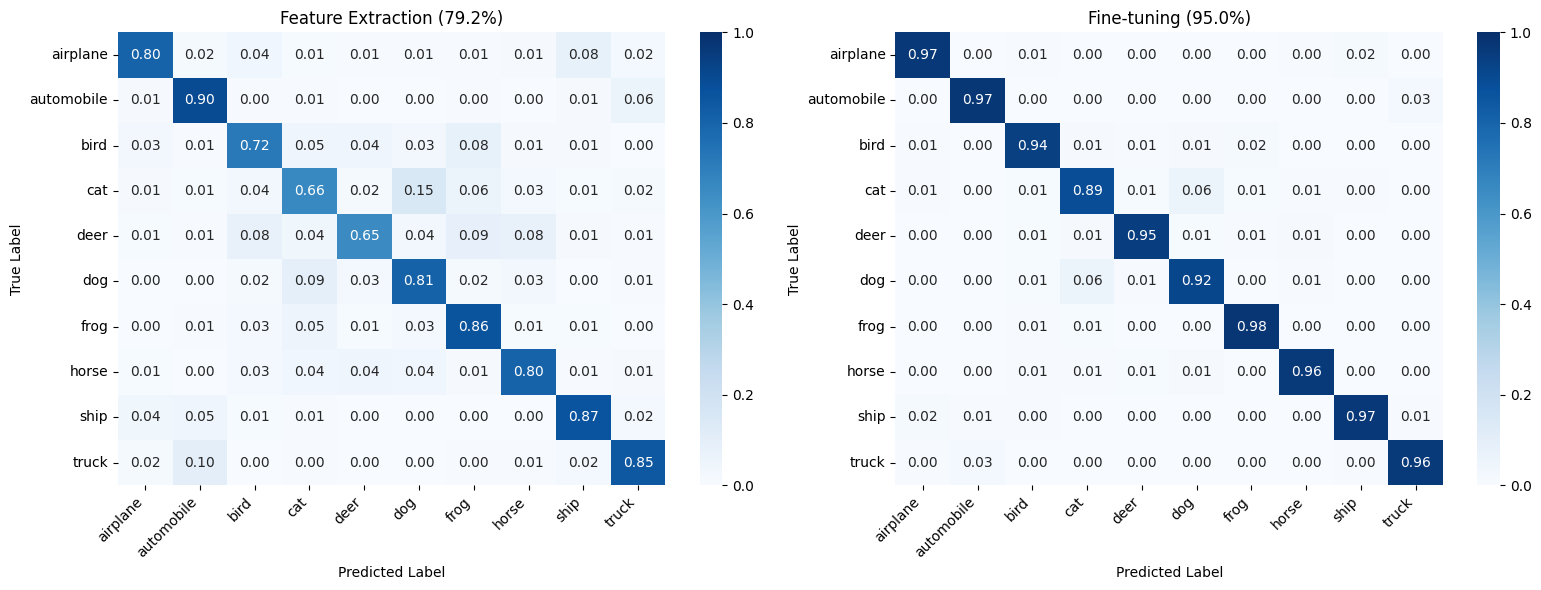


--- Classification Report: Feature Extraction ---
              precision    recall  f1-score   support

    airplane       0.85      0.80      0.83      1000
  automobile       0.82      0.90      0.86      1000
        bird       0.76      0.72      0.74      1000
         cat       0.69      0.66      0.67      1000
        deer       0.81      0.65      0.72      1000
         dog       0.73      0.81      0.77      1000
        frog       0.76      0.86      0.81      1000
       horse       0.82      0.80      0.81      1000
        ship       0.84      0.87      0.85      1000
       truck       0.85      0.85      0.85      1000

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.79     10000
weighted avg       0.79      0.79      0.79     10000


--- Classification Report: Fine-tuning ---
              precision    recall  f1-score   support

    airplane       0.96      0.97      0.96      1000
  automobile       0.97      0.97    

In [10]:
# --- Confusion Matrices ---
# A confusion matrix shows which classes get confused with each other.
# Rows = true labels, Columns = predicted labels.
# Diagonal = correct predictions. Off-diagonal = mistakes.
#
# We normalize by row (true label) so each cell shows the RECALL per class:
#   cell[i][j] = P(predict class j | true class is i)
#   diagonal cells = per-class accuracy
#
# What to look for:
#   Common CIFAR-10 confusions: cat↔dog, deer↔horse, automobile↔truck
#   Fine-tuning should reduce these confusions.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, labels, preds, title in [
    (axes[0], labels_fe, preds_fe, f'Feature Extraction ({acc_fe*100:.1f}%)'),
    (axes[1], labels_ft, preds_ft, f'Fine-tuning ({acc_ft*100:.1f}%)')
]:
    cm = confusion_matrix(labels, preds)
    # Normalize: divide each row by its sum to get per-class recall
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.2f',
        ax=ax,
        xticklabels=CLASSES,
        yticklabels=CLASSES,
        cmap='Blues',
        vmin=0,
        vmax=1
    )
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# classification_report gives per-class precision, recall and F1 score
# Precision: of all predicted as class X, how many were actually X?
# Recall:    of all true class X, how many did we correctly predict?
# F1:        harmonic mean of precision and recall
print('\n--- Classification Report: Feature Extraction ---')
print(classification_report(labels_fe, preds_fe, target_names=CLASSES))
print('\n--- Classification Report: Fine-tuning ---')
print(classification_report(labels_ft, preds_ft, target_names=CLASSES))

## 7. Grad-CAM — Where does the model "look"?

In [11]:
# =============================================================================
# GRAD-CAM (Gradient-weighted Class Activation Mapping)
# =============================================================================
# Goal: visualize which spatial regions of the image the model focuses on
# when making a prediction. This helps us understand and debug the model.
#
# How it works:
#   1. Run a forward pass → get the predicted class score
#   2. Backpropagate the score w.r.t. the feature maps of the last conv layer
#      → we get gradients: ∂score / ∂A^(l) for each feature map A
#   3. Average the gradients spatially (global average pooling)
#      → this gives an "importance weight" α_k for each feature map channel k
#   4. Weighted sum: CAM = ReLU( Σ_k α_k * A_k )
#      → ReLU keeps only regions that positively influence the class score
#   5. Upsample the CAM to the input image size and overlay as a heatmap
#
# Red = the model pays a lot of attention here
# Blue = the model ignores this region
#
# Why hook into layer4[-1].conv2?
#   This is the very last convolutional layer before the global average pool.
#   It produces the most abstract, class-discriminative feature maps.
#   Hooks are PyTorch's way to intercept tensors during forward/backward passes
#   without modifying the model architecture.
# =============================================================================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients  = None  # will store ∂score/∂feature_map
        self.activations = None  # will store the feature map values A^(l)

        # Register hooks on the target layer.
        # forward hook fires after the layer's forward pass → saves activations
        # backward hook fires after the layer's backward pass → saves gradients
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        # output shape: (1, C, H, W) — feature maps from this layer
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        # grad_output[0] shape: (1, C, H, W) — gradients flowing back through this layer
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()

        # Step 1: forward pass — this triggers _save_activation
        output = self.model(input_tensor)  # shape: (1, NUM_CLASSES)

        # Default: use the predicted class (highest logit)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        # Step 2: backward pass for the predicted class score only
        # This triggers _save_gradient
        self.model.zero_grad()
        output[0, class_idx].backward()

        # Step 3: global average pooling of gradients over spatial dims
        # α_k = (1/Z) Σ_{i,j} ∂score / ∂A^(l)_{k,i,j}
        # Result shape: (1, C, 1, 1) — one weight per feature map channel
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)

        # Step 4: weighted combination of feature maps
        # CAM = Σ_k α_k * A_k  → shape: (1, 1, H, W)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)

        # ReLU: only keep positive contributions
        # Negative values mean "this region suppresses the class" — we ignore those
        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().numpy()  # → (H, W) 2D array

        # Normalize to [0, 1] for visualization
        # Add 1e-8 to avoid division by zero for blank images
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


# For Feature Extraction: the frozen layers don't have requires_grad=True,
# so gradients can't flow back through them. We temporarily re-enable gradients
# for ALL parameters just for Grad-CAM visualization.
for param in model_fe.parameters():
    param.requires_grad = True

# Attach Grad-CAM to the last conv layer of each model
# layer4[1].conv2 = second conv of the last residual block
gradcam_fe = GradCAM(model_fe, model_fe.layer4[1].conv2)
gradcam_ft = GradCAM(model_ft, model_ft.layer4[1].conv2)

print('GradCAM hooks attached to layer4[1].conv2')

GradCAM hooks attached to layer4[1].conv2


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


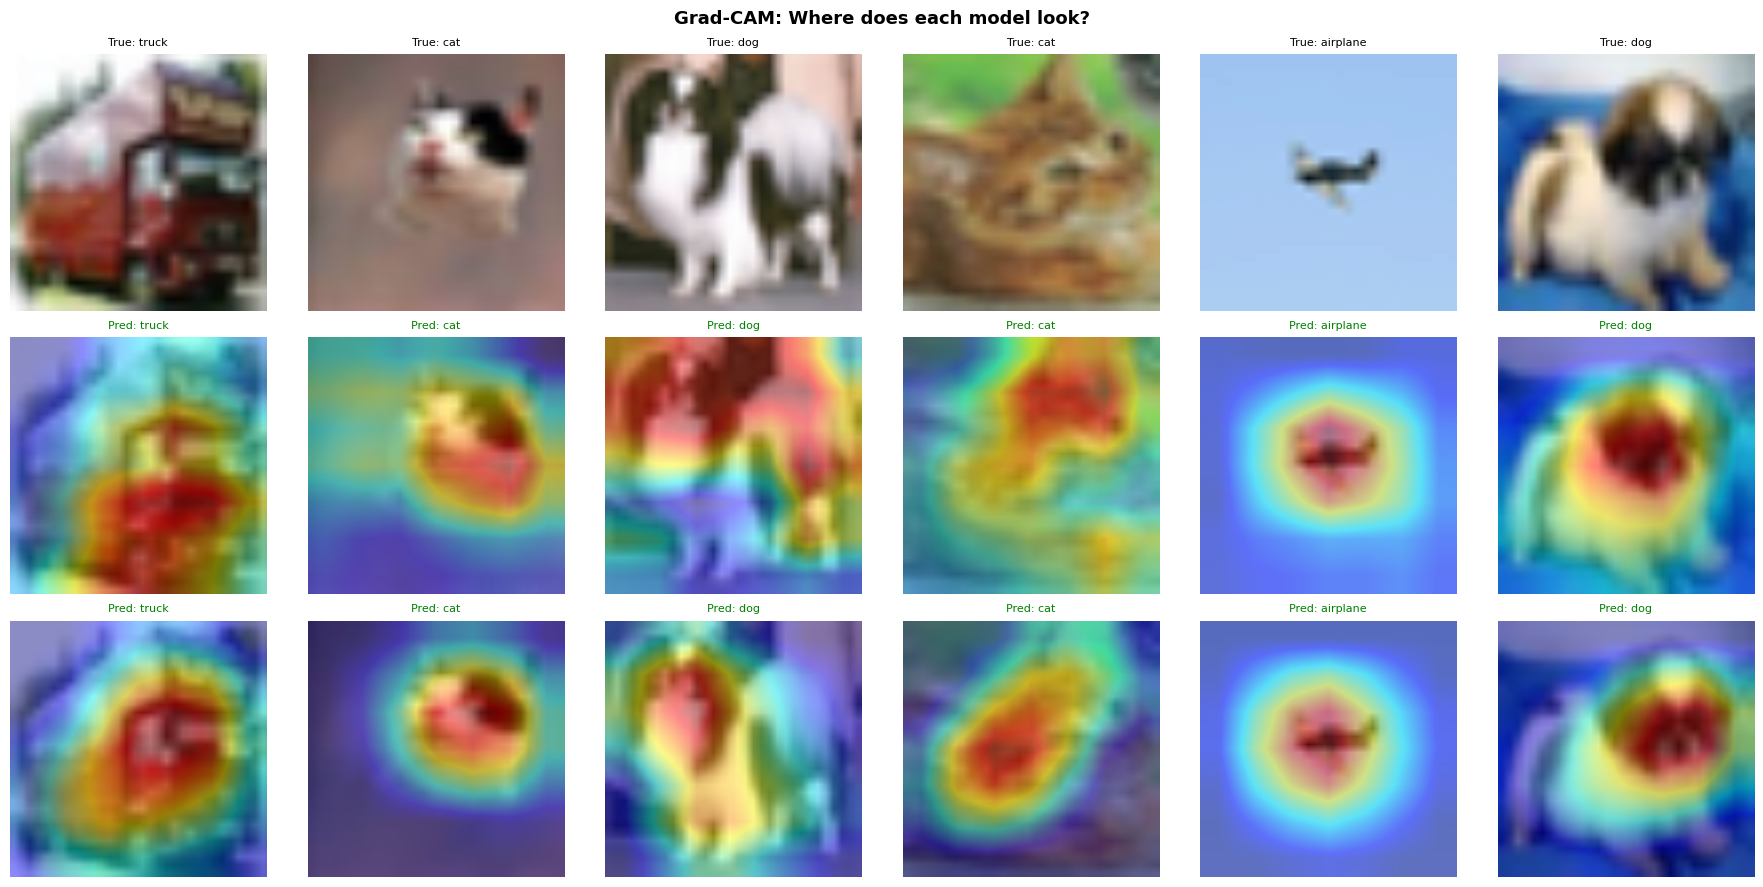

Saved: gradcam_comparison.png


In [12]:
import cv2

def denormalize(tensor):
    """
    Reverse the ImageNet normalization to recover the original pixel values.
    Formula: original = (normalized * std) + mean
    We clip to [0,1] to handle small floating point errors.
    """
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = tensor.permute(1, 2, 0).numpy()  # (C, H, W) → (H, W, C) for matplotlib
    img = img * std + mean
    return np.clip(img, 0, 1)


def overlay_heatmap(img_np, cam, alpha=0.45):
    """
    Blend a Grad-CAM heatmap on top of the original image.
    alpha controls the heatmap transparency (0=invisible, 1=fully opaque).
    JET colormap: blue=low attention, green=medium, red=high attention.
    """
    # Resize the low-resolution CAM (7x7 or 14x14) to the full image size (224x224)
    heatmap = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
    heatmap = np.uint8(255 * heatmap)                          # scale to 0-255
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)    # apply false color
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0  # BGR→RGB, scale to [0,1]
    # Blend: result = alpha * heatmap + (1-alpha) * original_image
    return np.clip(alpha * heatmap + (1 - alpha) * img_np, 0, 1)


# Sample 6 random test images for visualization
test_images, test_labels = next(iter(torch.utils.data.DataLoader(
    test_dataset,
    batch_size=6,
    shuffle=True
)))

# Grid layout: 3 rows x 6 columns
# Row 0: original images
# Row 1: Feature Extraction Grad-CAM
# Row 2: Fine-tuning Grad-CAM
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle('Grad-CAM: Where does each model look?', fontsize=13, fontweight='bold')

row_titles = ['Original', 'Feature Extraction', 'Fine-tuning']

for col, (img, lbl) in enumerate(zip(test_images, test_labels)):

    img_np = denormalize(img)  # recover original pixel values for display

    # Add batch dimension (unsqueeze) and send to GPU
    # requires_grad_(True) is needed so backprop can flow through the input
    inp = img.unsqueeze(0).to(device).requires_grad_(True)

    # Generate Grad-CAM for each model
    cam_fe, pred_fe = gradcam_fe.generate(inp)
    cam_ft, pred_ft = gradcam_ft.generate(inp)

    # Row 0: original image
    axes[0, col].imshow(img_np)
    axes[0, col].set_title(f'True: {CLASSES[lbl]}', fontsize=8)
    axes[0, col].axis('off')

    # Row 1: Feature Extraction heatmap
    # Green title = correct prediction, Red = wrong prediction
    axes[1, col].imshow(overlay_heatmap(img_np, cam_fe))
    axes[1, col].set_title(f'Pred: {CLASSES[pred_fe]}', fontsize=8,
                            color='green' if pred_fe == lbl.item() else 'red')
    axes[1, col].axis('off')

    # Row 2: Fine-tuning heatmap
    axes[2, col].imshow(overlay_heatmap(img_np, cam_ft))
    axes[2, col].set_title(f'Pred: {CLASSES[pred_ft]}', fontsize=8,
                            color='green' if pred_ft == lbl.item() else 'red')
    axes[2, col].axis('off')

# Add row labels on the left side
for ax, title in zip(axes[:, 0], row_titles):
    ax.set_ylabel(title, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('gradcam_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: gradcam_comparison.png')
# What to look for in the output:
# - Does fine-tuning focus more tightly on the object itself?
# - Does feature extraction sometimes look at the background?
# - For wrong predictions: is the heatmap on the wrong region?

## 8. Final Summary

In [13]:
print('=' * 60)
print('RESULTS SUMMARY')
print('=' * 60)
print(f'  Feature Extraction')
print(f'    Test Accuracy    : {acc_fe*100:.2f}%')
print(f'    Trainable Params : {count_trainable_params(model_fe):,}')
print(f'    Training Time    : {time_fe/60:.1f} min')
print()
print(f'  Fine-tuning')
print(f'    Test Accuracy    : {acc_ft*100:.2f}%')
print(f'    Trainable Params : {count_trainable_params(model_ft):,}')
print(f'    Training Time    : {time_ft/60:.1f} min')
print()
print(f'  Accuracy gain from fine-tuning : {(acc_ft - acc_fe)*100:+.2f}%')
print('=' * 60)
print()
print('CONCLUSION:')
print('Fine-tuning allows the last conv layers to adapt to CIFAR-10')
print('at the cost of more trainable parameters and longer training.')
print('Feature extraction is faster and still performs well because')
print('ImageNet and CIFAR-10 share similar low-level visual features.')
print()
print('Key insight: the accuracy gap shows how much the last layers')
print('of ResNet18 were tuned for ImageNet and not for CIFAR-10.')
print('If the gap is large → fine-tuning is worth it.')
print('If the gap is small → feature extraction is sufficient.')

RESULTS SUMMARY
  Feature Extraction
    Test Accuracy    : 79.19%
    Trainable Params : 11,181,642
    Training Time    : 25.9 min

  Fine-tuning
    Test Accuracy    : 94.95%
    Trainable Params : 10,498,570
    Training Time    : 27.5 min

  Accuracy gain from fine-tuning : +15.76%

CONCLUSION:
Fine-tuning allows the last conv layers to adapt to CIFAR-10
at the cost of more trainable parameters and longer training.
Feature extraction is faster and still performs well because
ImageNet and CIFAR-10 share similar low-level visual features.

Key insight: the accuracy gap shows how much the last layers
of ResNet18 were tuned for ImageNet and not for CIFAR-10.
If the gap is large → fine-tuning is worth it.
If the gap is small → feature extraction is sufficient.
